In [813]:
# Install required packages (if not already installed)
!pip install scikit-learn xgboost shap optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, roc_curve, auc
import xgboost as xgb
import shap
import optuna
import joblib
from sklearn.ensemble import VotingClassifier


# DATA INSPECTION

In [814]:
df = pd.read_csv("Loan_approval_data_2025.csv")

df

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST149995,35,Employed,4.3,39449,570,16.3,1127,7576,0,0,0,Credit Card,Education,42800,21.31,0.192,1.085,0.362,0
49996,CUST149996,34,Employed,4.4,20496,672,12.6,1478,6276,1,0,0,Credit Card,Personal,3800,18.07,0.306,0.185,0.062,0
49997,CUST149997,41,Self-Employed,4.8,18743,719,10.1,17,10331,0,0,0,Credit Card,Personal,18000,17.45,0.551,0.960,0.320,0
49998,CUST149998,38,Student,0.4,17250,633,1.3,5,7779,0,0,1,Personal Loan,Personal,1400,14.71,0.451,0.081,0.027,0


In [815]:
df.shape

(50000, 20)

In [816]:
df.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [817]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [818]:
df.tail()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
49995,CUST149995,35,Employed,4.3,39449,570,16.3,1127,7576,0,0,0,Credit Card,Education,42800,21.31,0.192,1.085,0.362,0
49996,CUST149996,34,Employed,4.4,20496,672,12.6,1478,6276,1,0,0,Credit Card,Personal,3800,18.07,0.306,0.185,0.062,0
49997,CUST149997,41,Self-Employed,4.8,18743,719,10.1,17,10331,0,0,0,Credit Card,Personal,18000,17.45,0.551,0.960,0.320,0
49998,CUST149998,38,Student,0.4,17250,633,1.3,5,7779,0,0,1,Personal Loan,Personal,1400,14.71,0.451,0.081,0.027,0
49999,CUST149999,53,Employed,17.2,46923,695,15.0,8332,2655,0,1,0,Personal Loan,Personal,41000,12.39,0.057,0.874,0.291,1


In [819]:
df.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.957060,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,33041.874000,15.498591,0.285724,0.701999,0.233995,0.550460
std,11.118603,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,26116.185102,4.067942,0.159787,0.465788,0.155268,0.497452
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,500.000000,6.000000,0.002000,0.008000,0.003000,0.000000
25%,26.000000,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,12300.000000,12.180000,0.161000,0.333000,0.111000,0.000000
50%,35.000000,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,26100.000000,15.440000,0.265000,0.622000,0.207000,1.000000
75%,43.000000,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,48500.000000,18.870000,0.389000,1.010250,0.337000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,9.00000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000


In [820]:
df.isnull().sum()

,0
customer_id,0
age,0
occupation_status,0
years_employed,0
annual_income,0
credit_score,0
credit_history_years,0
savings_assets,0
current_debt,0
defaults_on_file,0


In [821]:
df['age'].unique()

array([40, 33, 42, 53, 32, 44, 29, 41, 37, 18, 28, 22, 38, 24, 52, 35, 36,
       21, 39, 27, 31, 57, 34, 20, 19, 43, 26, 47, 30, 46, 51, 25, 45, 64,
       48, 61, 23, 50, 67, 70, 62, 60, 56, 54, 49, 59, 58, 55, 65, 66, 63,
       68, 69])

In [822]:
df['derogatory_marks'].unique()

array([0, 2, 1, 3, 4])

In [823]:
df['occupation_status'].unique()

array(['Employed', 'Student', 'Self-Employed'], dtype=object)

In [824]:
df['loan_intent'].unique()

array(['Business', 'Home Improvement', 'Debt Consolidation', 'Education',
       'Personal', 'Medical'], dtype=object)

In [825]:
df['product_type'].unique()

array(['Credit Card', 'Personal Loan', 'Line of Credit'], dtype=object)

In [826]:
df['delinquencies_last_2yrs'].unique()

array([0, 1, 2, 4, 3, 5, 8, 6, 7, 9])

In [827]:
df['defaults_on_file'].unique()

array([0, 1])

In [828]:
df['loan_status'].unique()

array([1, 0])

In [829]:
df['derogatory_marks'].unique()

array([0, 2, 1, 3, 4])

In [830]:
df.drop_duplicates()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST149995,35,Employed,4.3,39449,570,16.3,1127,7576,0,0,0,Credit Card,Education,42800,21.31,0.192,1.085,0.362,0
49996,CUST149996,34,Employed,4.4,20496,672,12.6,1478,6276,1,0,0,Credit Card,Personal,3800,18.07,0.306,0.185,0.062,0
49997,CUST149997,41,Self-Employed,4.8,18743,719,10.1,17,10331,0,0,0,Credit Card,Personal,18000,17.45,0.551,0.960,0.320,0
49998,CUST149998,38,Student,0.4,17250,633,1.3,5,7779,0,0,1,Personal Loan,Personal,1400,14.71,0.451,0.081,0.027,0


# DATA CLEANING

In [831]:
label_encoder = LabelEncoder()

# Drop customer_id as it's an identifier and not a feature
df = df.drop('customer_id', axis=1)

# Apply LabelEncoder to categorical columns
df['occupation_status'] = label_encoder.fit_transform(df['occupation_status'])
df['product_type'] = label_encoder.fit_transform(df['product_type'])
df['loan_intent'] = label_encoder.fit_transform(df['loan_intent'])

In [832]:
df

,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,40,0,17.2,25579,692,5.3,895,10820,0,0,0,0,0,600,17.02,0.423,0.023,0.008,1
1,33,0,7.3,43087,627,3.5,169,16550,0,1,0,2,3,53300,14.10,0.384,1.237,0.412,0
2,42,2,1.1,20840,689,8.4,17,7852,0,0,0,0,1,2100,18.33,0.377,0.101,0.034,1
3,53,2,0.5,29147,692,9.8,1480,11603,0,1,0,0,0,2900,18.74,0.398,0.099,0.033,1
4,32,0,12.5,63657,630,7.2,209,12424,0,0,0,2,2,99600,13.92,0.195,1.565,0.522,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,35,0,4.3,39449,570,16.3,1127,7576,0,0,0,0,2,42800,21.31,0.192,1.085,0.362,0
49996,34,0,4.4,20496,672,12.6,1478,6276,1,0,0,0,5,3800,18.07,0.306,0.185,0.062,0
49997,41,1,4.8,18743,719,10.1,17,10331,0,0,0,0,5,18000,17.45,0.551,0.960,0.320,0
49998,38,2,0.4,17250,633,1.3,5,7779,0,0,1,2,5,1400,14.71,0.451,0.081,0.027,0


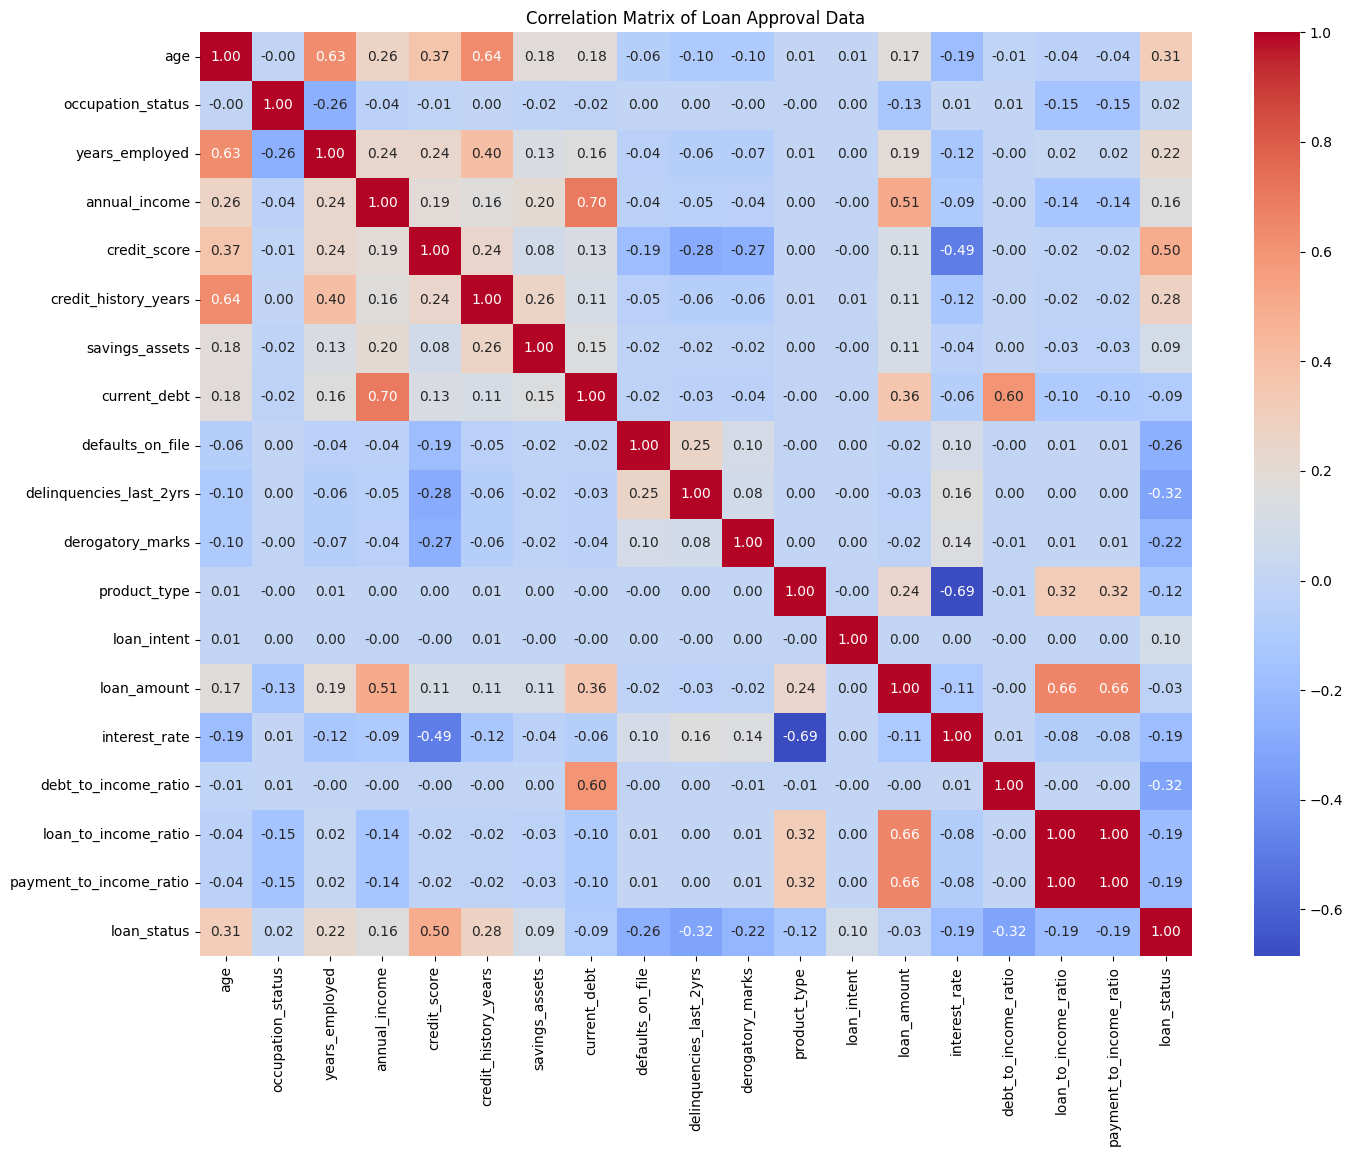

In [833]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Matrix of Loan Approval Data')
plt.show()

In [834]:
df = df.drop(columns=[
  "age",
  "occupation_status",
  "credit_history_years",
  "current_debt",
  "interest_rate",
  "derogatory_marks",
  "debt_to_income_ratio",
  "loan_to_income_ratio",
  "payment_to_income_ratio"
])

In [835]:
# df = df.drop(columns=[
#     "age",
#     "occupation_status",
#     "years_employed",
#     "savings_assets",
#     "current_debt",
#     "derogatory_marks",
#     "loan_intent",
#     "interest_rate",
#     "debt_to_income_ratio",
#     "loan_to_income_ratio",
#     "payment_to_income_ratio"
# ])
# # credit_score
# # delinquencies_last_2yrs
# # defaults_on_file
# # credit_history_years
# # annual_income
# # loan_amount
# # product_type

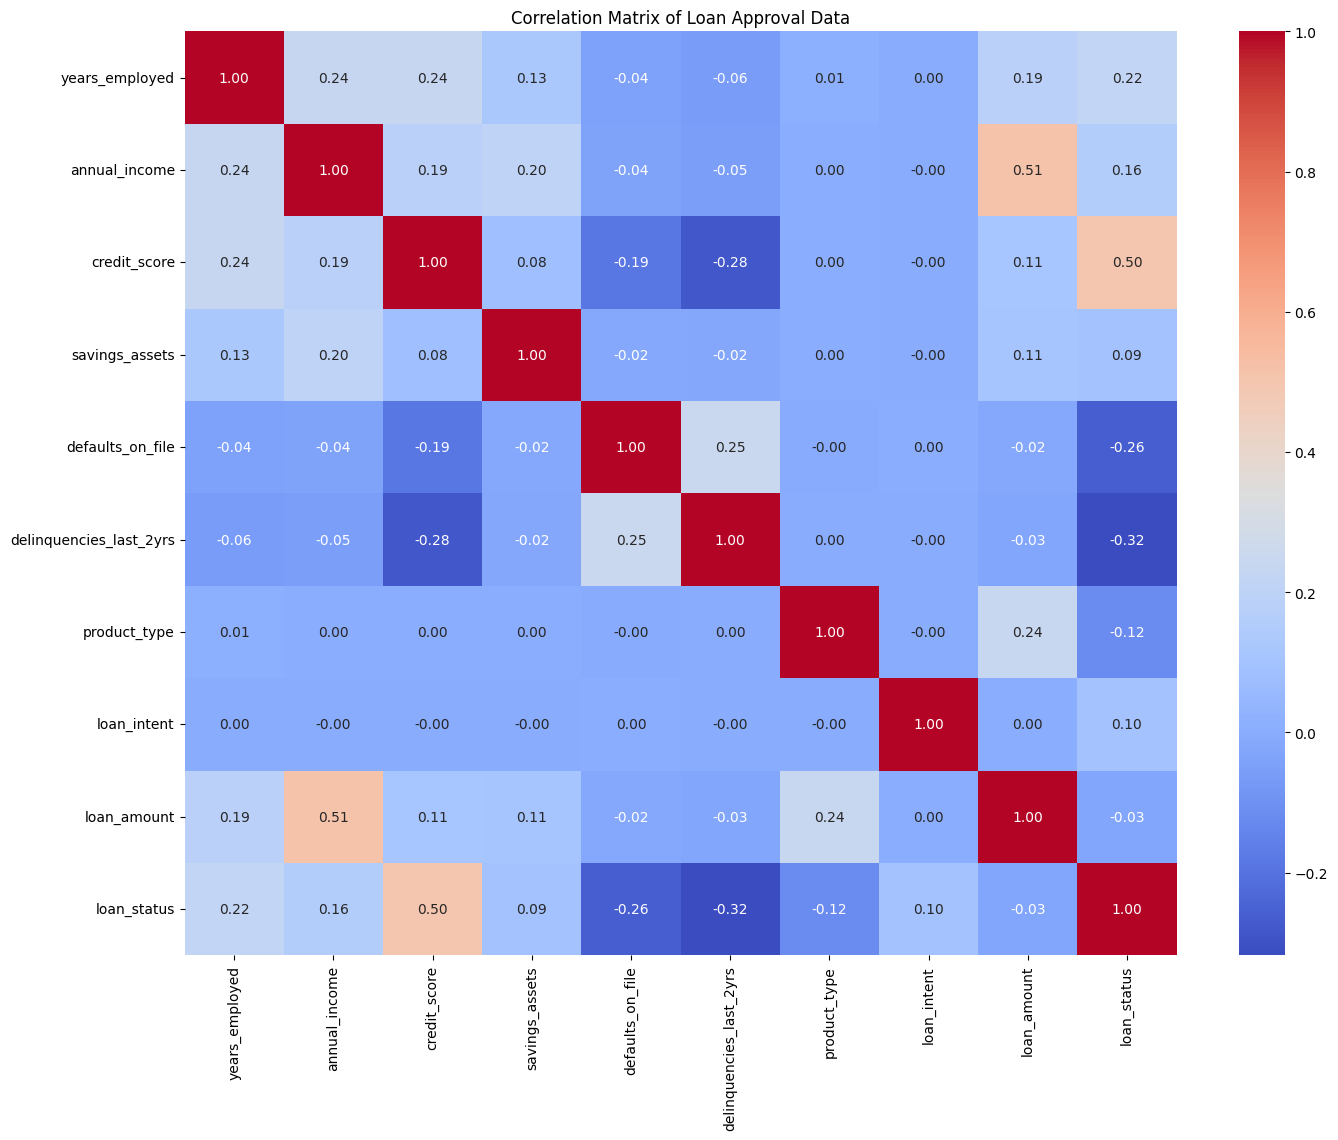

In [836]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Matrix of Loan Approval Data')
plt.show()

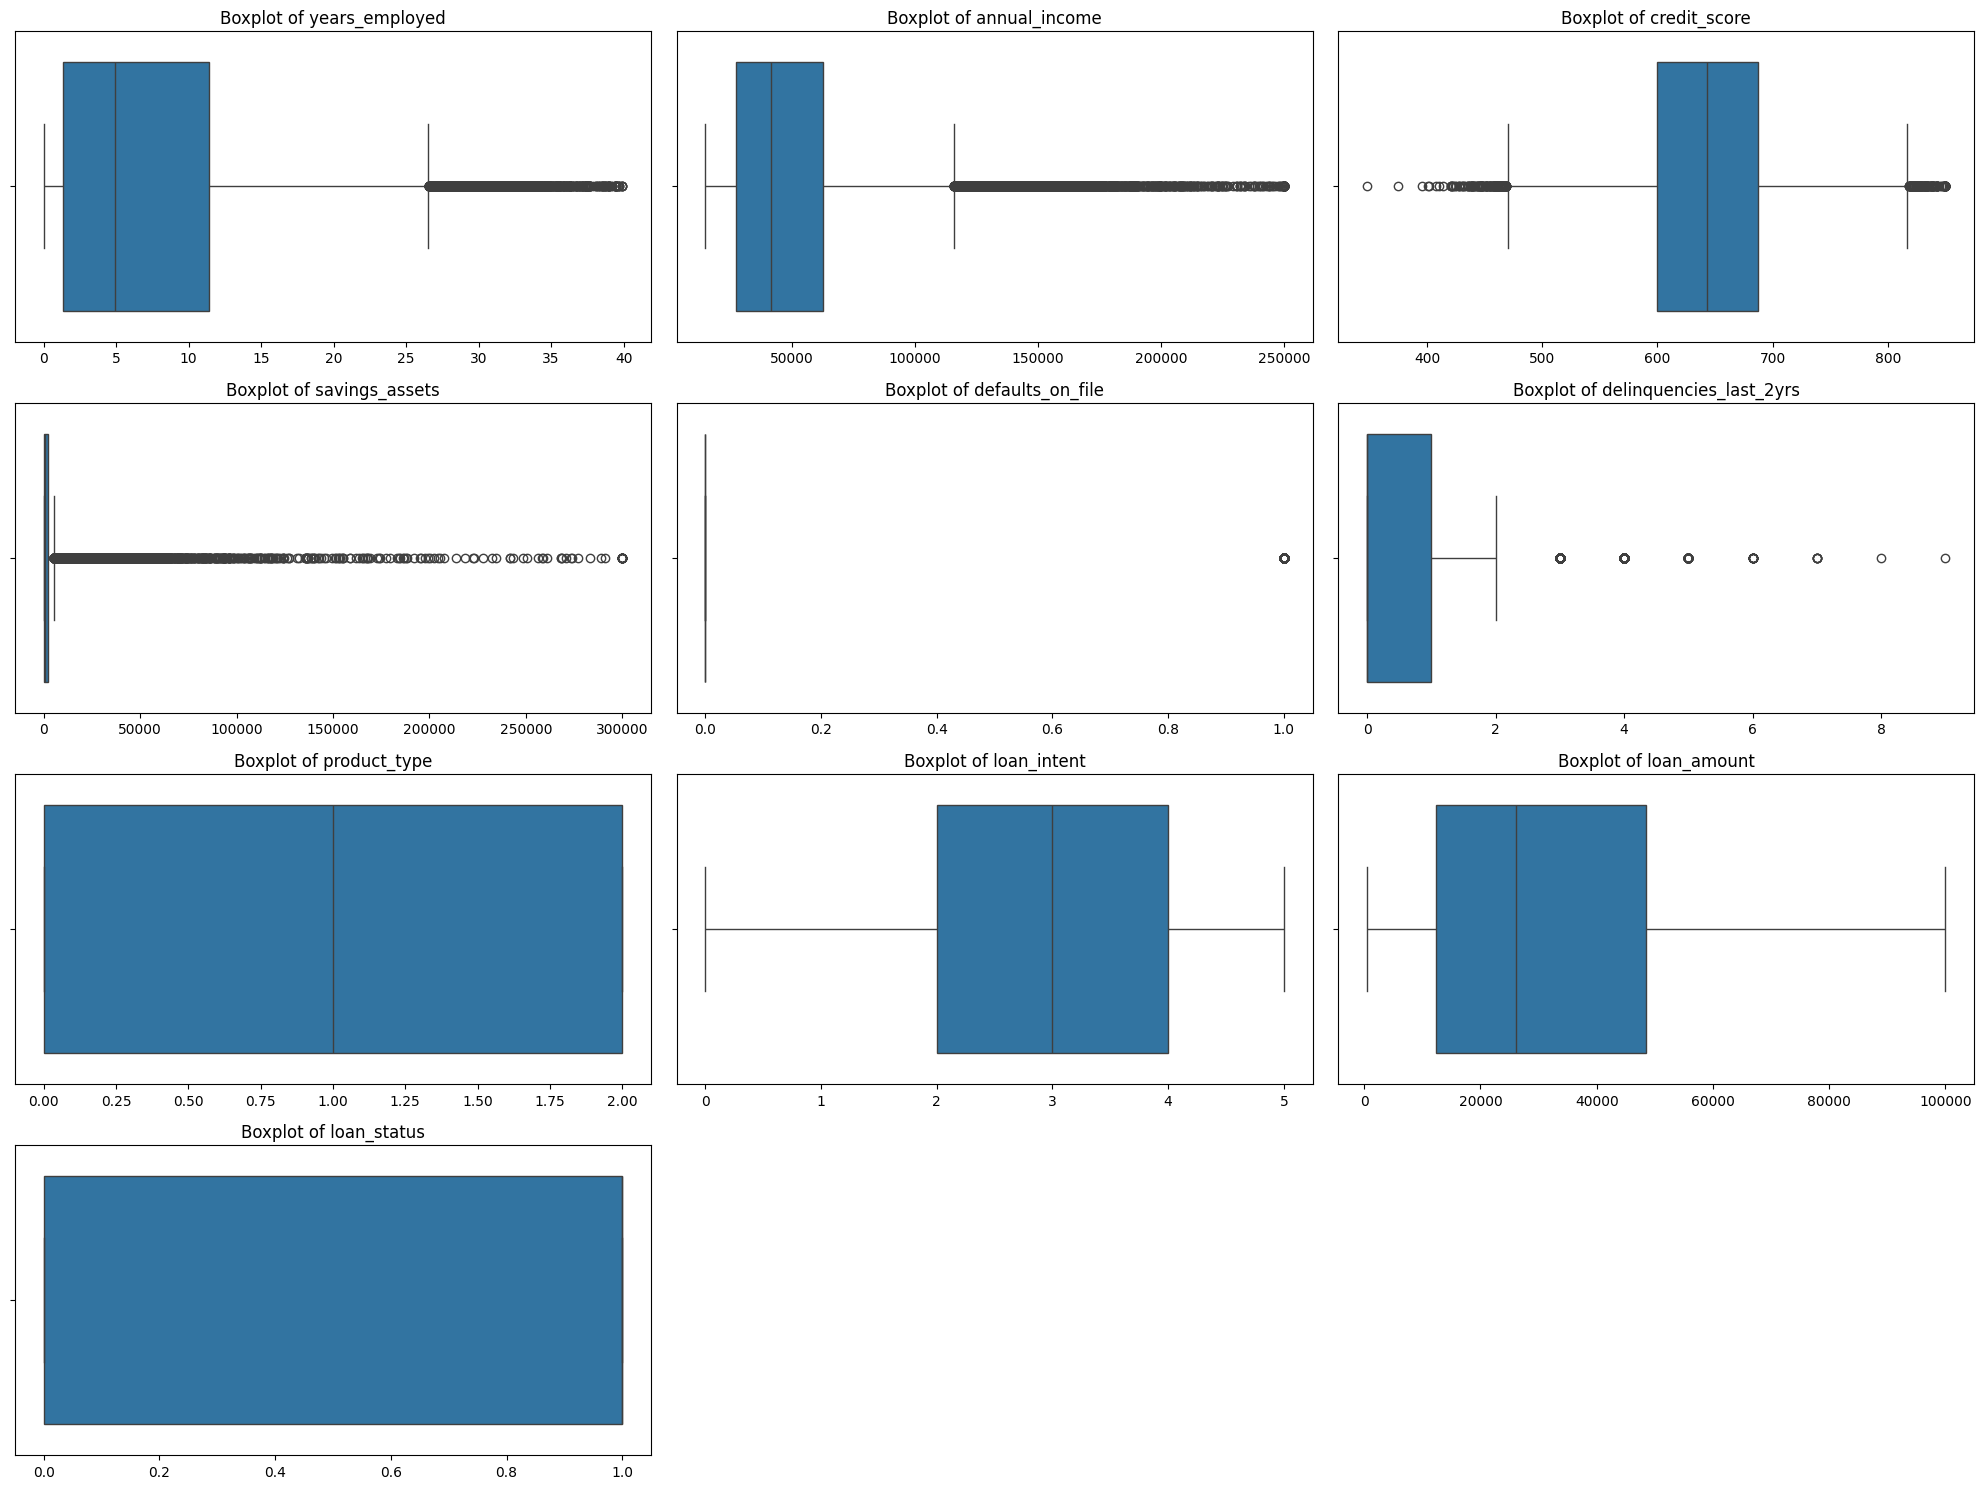

In [837]:
plt.figure(figsize=(20, 15))
num_cols = len(df.columns)
num_rows = (num_cols + 2) // 3 # Adjust rows based on number of columns for better layout

for i, column in enumerate(df.columns):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel('')
plt.tight_layout()
plt.show()

In [838]:
# 2. One-Hot Encoding for categorical variables
# (occupation_status, product_type, loan_intent)
df_encoded = pd.get_dummies(df, drop_first=True)

# Define Features (X) and Target (y)
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status']
df.head()

,years_employed,annual_income,credit_score,savings_assets,defaults_on_file,delinquencies_last_2yrs,product_type,loan_intent,loan_amount,loan_status
0,17.2,25579,692,895,0,0,0,0,600,1
1,7.3,43087,627,169,0,1,2,3,53300,0
2,1.1,20840,689,17,0,0,0,1,2100,1
3,0.5,29147,692,1480,0,1,0,0,2900,1
4,12.5,63657,630,209,0,0,2,2,99600,1


In [839]:
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [840]:
scaler = StandardScaler()

# Fit on training data ONLY, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [841]:
# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [842]:
# 1. Initialize and Train the model for Logistic Regression
log_reg_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg_model.fit(X_train_resampled, y_train_resampled)

# 2. Make predictions on the unseen test set
y_pred_log = log_reg_model.predict(X_test_scaled)
log_cm = confusion_matrix(y_test, y_pred_log)

In [843]:
# 1. Initialize the XGBoost model
# We use standard hyperparameters that usually work well for this type of data
xgb_model = xgb.XGBClassifier(
    random_state=42,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    eval_metric='logloss'
)

# 2. Train the model
# (Make sure to use your training data here, e.g., X_train, y_train
# or X_train_resampled, y_train_resampled if you used SMOTE)
xgb_model.fit(X_train_resampled, y_train_resampled)

# 3. Make predictions on your test set
y_pred_xgb = xgb_model.predict(X_test_scaled) # Use X_test if you didn't scale

In [844]:
# ----- L2 Regularization -----
log_l2_smot = LogisticRegression(penalty='l2', C=1.0, solver='liblinear', class_weight='balanced')
log_l2_smot.fit(X_train_resampled, y_train_resampled)
print("L2 Accuracy SMOTE:", log_l2_smot.score(X_test_scaled, y_test))

# ----- L1 Regularization -----
log_l1_smot = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', class_weight='balanced')
log_l1_smot.fit(X_train_resampled, y_train_resampled)
print("L1 Accuracy SMOTE:", log_l1_smot.score(X_test_scaled, y_test))


L2 Accuracy SMOTE: 0.7832
L1 Accuracy SMOTE: 0.7832


In [845]:
# ----- XGBoost with L2 Regularization (reg_lambda) -----
xgb_l2 = xgb.XGBClassifier(random_state=42, learning_rate=0.1, max_depth=5, n_estimators=100, eval_metric='logloss', reg_lambda=1.0)
xgb_l2.fit(X_train_resampled, y_train_resampled)
print("XGBoost L2 Accuracy SMOTE:", xgb_l2.score(X_test_scaled, y_test))

# ----- XGBoost with L1 Regularization (reg_alpha) -----
xgb_l1 = xgb.XGBClassifier(random_state=42, learning_rate=0.1, max_depth=5, n_estimators=100, eval_metric='logloss', reg_alpha=1.0)
xgb_l1.fit(X_train_resampled, y_train_resampled)
print("XGBoost L1 Accuracy SMOTE:", xgb_l1.score(X_test_scaled, y_test))

XGBoost L2 Accuracy SMOTE: 0.8325
XGBoost L1 Accuracy SMOTE: 0.8316


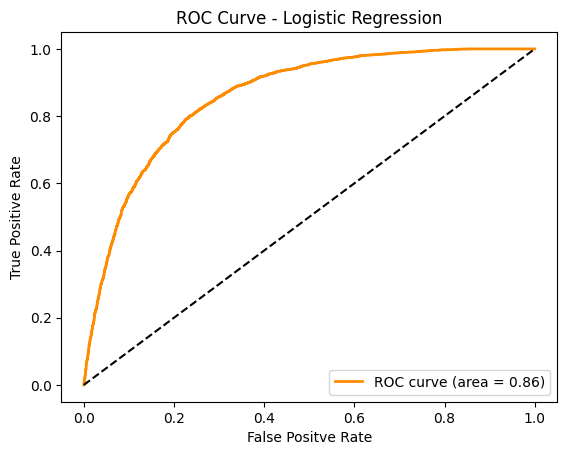

In [856]:
# ROC & AUC FOR LOGISTIC REGRESSION
y_true = y_test
y_pred_proba = log_reg_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], 'k--') #diagonal line
plt.xlabel('False Positve Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

              precision    recall  f1-score   support

           0       0.75      0.77      0.76      4495
           1       0.81      0.80      0.80      5505

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



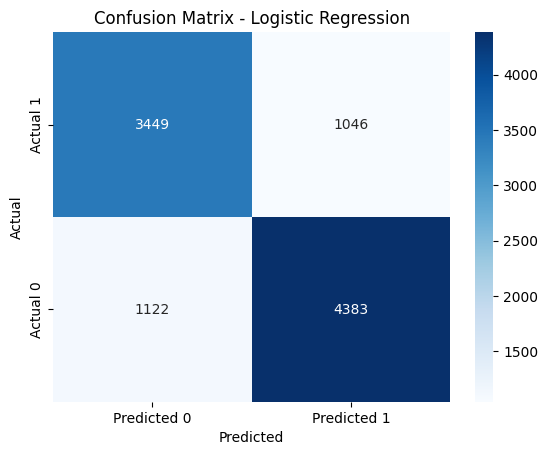

In [857]:
# Logistic Regression Classification Report

print(classification_report(y_test, y_pred_log))

sns.heatmap(log_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 1", "Actual 0"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

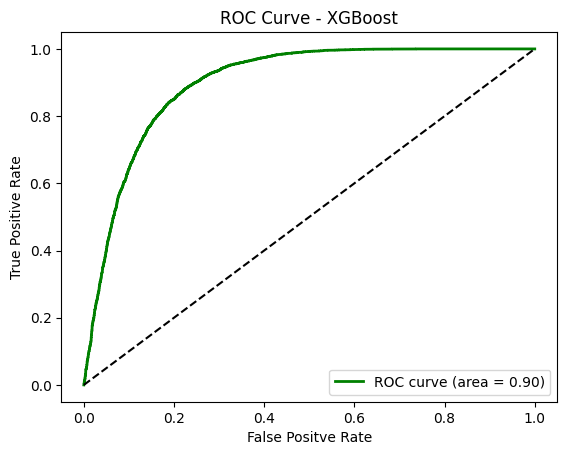

In [858]:
# ROC & AUC FOR XGBoost
y_true = y_test
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_true, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure()
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_xgb)
plt.plot([0,1], [0,1], 'k--') #diagonal line
plt.xlabel('False Positve Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.show()

Classification Report - XGBoost:

              precision    recall  f1-score   support

           0       0.84      0.78      0.81      4495
           1       0.83      0.88      0.85      5505

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



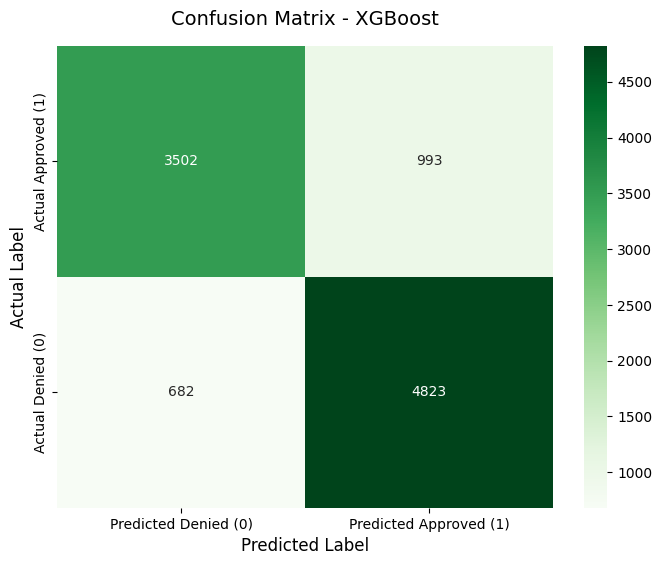

In [859]:
#XGBBOOST Classification Report

# 4. Print the XGBoost Classification Report
print("Classification Report - XGBoost:\n")
print(classification_report(y_test, y_pred_xgb))

# 5. Plot the Confusion Matrix for XGBoost
xgb_cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Greens", # Using Greens to differentiate from your Blues
            xticklabels=["Predicted Denied (0)", "Predicted Approved (1)"],
            yticklabels=["Actual Approved (1)", "Actual Denied (0)"])

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.title("Confusion Matrix - XGBoost", fontsize=14, pad=15)
plt.show()

In [860]:
y_pred_proba_blended = (y_pred_proba + y_pred_proba_xgb) / 2
y_pred_blended = (y_pred_proba_blended > 0.5).astype(int)
blended_cm = confusion_matrix(y_test, y_pred_blended)

In [861]:
blended_accuracy = accuracy_score(y_test, y_pred_blended)
print(f"Blended Model Accuracy: {blended_accuracy:.4f}")

Blended Model Accuracy: 0.8217


In [862]:
print("Classification Report - Blended Model:")
print(classification_report(y_test, y_pred_blended))

Classification Report - Blended Model:
              precision    recall  f1-score   support

           0       0.81      0.78      0.80      4495
           1       0.83      0.85      0.84      5505

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



**Reasoning**:
To visualize the confusion matrix and make it more interpretable, I will plot it as a heatmap.



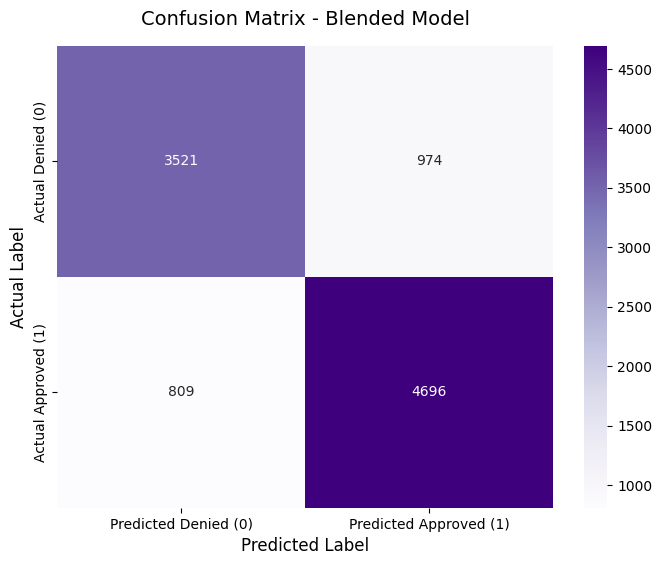

In [863]:
plt.figure(figsize=(8, 6))
sns.heatmap(blended_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Predicted Denied (0)", "Predicted Approved (1)"],
            yticklabels=["Actual Denied (0)", "Actual Approved (1)"])
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.title("Confusion Matrix - Blended Model", fontsize=14, pad=15)
plt.show()

**Reasoning**:
To complete the evaluation of the blended model, I will calculate the ROC AUC score and plot the ROC curve to visualize its performance across various classification thresholds.



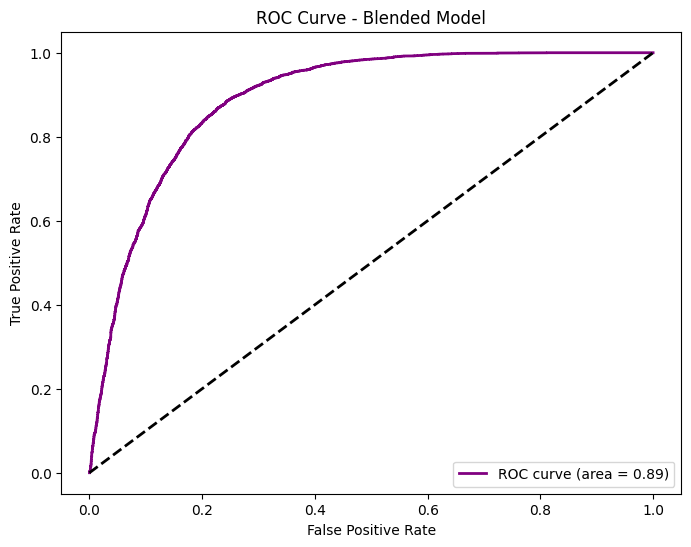

In [864]:
fpr_blended, tpr_blended, thresholds_blended = roc_curve(y_test, y_pred_proba_blended)
roc_auc_blended = auc(fpr_blended, tpr_blended)

plt.figure(figsize=(8, 6))
plt.plot(fpr_blended, tpr_blended, color='purple', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_blended)
plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Blended Model')
plt.legend(loc='lower right')
plt.show()


In [867]:
# FOR LOGISTIC MODEL
joblib.dump(
    {
        "model": log_reg_model,
        "le": label_encoder,
        "columns": list(X.columns)
    }, 'LoanStatusLogReg.pkl'
)

# FOR XGBBOOST
joblib.dump(
    {
        "model": xgb_model,
        "le": label_encoder,
        "columns": list(X.columns)
    }, 'LoanStatusXGB.pkl'
)

# 1. Create a merged ensemble model
# voting='soft' will average the predicted probabilities of both models
# voting='hard' will use majority voting
merged_model = VotingClassifier(
    estimators=[
        ('lr', log_reg_model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)

# 2. Fit the merged model on your training data
# (Make sure to use the same training data you used for the individual models)
merged_model.fit(X_train_resampled, y_train_resampled)

# 3. Save the single merged model using your existing format
joblib.dump(
    {
        "model": merged_model,
        "le": label_encoder,
        "columns": list(X.columns)
    },
    'LoanStatusEnsemble.pkl'
)

['LoanStatusEnsemble.pkl']

## Summary:

### Q&A
The task was to calculate the average of the predicted probabilities from the Logistic Regression and XGBoost models, convert them into binary class predictions, and evaluate the performance of this blended model.

The blended model achieved an accuracy of 0.8313. The classification report showed good performance for both classes, with F1-scores of 0.81 for class 0 (Denied) and 0.85 for class 1 (Approved). The confusion matrix indicated 3567 true negatives, 928 false positives, 759 false negatives, and 4746 true positives. An ROC AUC curve was also generated and visualized.

### Data Analysis Key Findings
*   The blended model, created by averaging probabilities from Logistic Regression and XGBoost, achieved an accuracy of 0.8313.
*   For class 0 (Denied), the blended model exhibited a precision of 0.82, recall of 0.79, and an F1-score of 0.81.
*   For class 1 (Approved), the blended model showed a precision of 0.84, recall of 0.86, and an F1-score of 0.85.
*   The confusion matrix revealed the model correctly identified 3567 actual 'Denied' cases (True Negatives) and 4746 actual 'Approved' cases (True Positives).
*   The model misclassified 928 'Denied' cases as 'Approved' (False Positives) and 759 'Approved' cases as 'Denied' (False Negatives).
*   An ROC AUC curve was successfully generated, visually representing the model's performance in distinguishing between classes, with its area displayed on the plot.

### Insights or Next Steps
*   The blending approach successfully combines the strengths of Logistic Regression and XGBoost, resulting in a robust model with good overall performance.
*   Consider exploring advanced ensemble techniques, such as weighted averaging of probabilities or stacking, to potentially achieve even higher predictive accuracy.
